In [9]:
from sklearn.exceptions import ConvergenceWarning
import warnings

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import utils, layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [11]:
df = pd.read_csv(r"D:\Summer_2025_ML_Internships\Developer_HUB_ML_Tasks\Advanced\House_Price_Prediction\real_estate_dataset\Housing_data.csv")
df.head(3)

,image_id,street,citi,n_citi,bed,bath,sqft,price
0,0,1317 Van Buren Avenue,"Salton City, CA",317,3,2.0,1560,201900
1,1,124 C Street W,"Brawley, CA",48,3,2.0,713,228500
2,2,2304 Clark Road,"Imperial, CA",152,3,1.0,800,273950


In [13]:
df["image_path"] = df["image_id"].map(lambda x: f"D:\\Summer_2025_ML_Internships\\Developer_HUB_ML_Tasks\\Advanced\\House_Price_Prediction\\real_estate_dataset\\socal_pics\\{x}.jpg")

In [14]:
df.head(3)

,image_id,street,citi,n_citi,bed,bath,sqft,price,image_path
0,0,1317 Van Buren Avenue,"Salton City, CA",317,3,2.0,1560,201900,D:\Summer_2025_ML_Internships\Developer_HUB_ML...
1,1,124 C Street W,"Brawley, CA",48,3,2.0,713,228500,D:\Summer_2025_ML_Internships\Developer_HUB_ML...
2,2,2304 Clark Road,"Imperial, CA",152,3,1.0,800,273950,D:\Summer_2025_ML_Internships\Developer_HUB_ML...


In [15]:
print(df["citi"].value_counts())
print(df["n_citi"].value_counts())
# df.describe()

citi
San Diego, CA      707
Los Angeles, CA    388
Lancaster, CA      312
La Quinta, CA      305
Riverside, CA      274
                  ... 
Parkfield, CA        1
New Cuyama, CA       1
Cuyama, CA           1
Montecito, CA        1
Imperial, CA         1
Name: count, Length: 415, dtype: int64
n_citi
320    707
207    388
193    312
175    305
310    274
      ... 
273      1
236      1
95       1
224      1
152      1
Name: count, Length: 415, dtype: int64


In [16]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

In [17]:
features = ["sqft", "bed", "n_citi", "bath"]

train_features = train_df[features].values
val_features   = val_df[features].values

imageSize = (128,128)
batch = 64

datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="price",
    target_size=imageSize,
    batch_size=batch,
    class_mode="raw",
    shuffle=True
)

val_gen = datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="price",
    target_size=imageSize,
    batch_size=batch,
    class_mode="raw",
    shuffle=True
)

Found 12379 validated image filenames.
Found 3095 validated image filenames.


In [18]:
#next(train_gen)

In [19]:
i = 0

def my_generator(train_gen, features):
  i=0
  while True:
    images, target = next(train_gen)
    tabular_feature = features[i:i+batch]
    i += batch
    if i >= len(features):
      i = 0
    yield (images, tabular_feature), target

train = my_generator(train_gen, train_features)
validation  = my_generator(val_gen, val_features)

In [28]:
def rmse(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    return tf.sqrt(tf.reduce_mean(tf.square(y_pred - y_true)))

# model.compile(
#     optimizer="adam",
#     loss="mse",
#     metrics=["mae", rmse]
# )

In [29]:
image_input = layers.Input(shape=(128, 128, 3), name="image_input")
x = layers.Conv2D(32, (3, 3), activation='relu', padding="same")(image_input)
x = layers.Conv2D(32, (3, 3), activation='relu', padding="same")(x)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding="same")(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding="same")(x)
x = layers.MaxPooling2D()(x)
x = layers.Flatten()(x)

tab_input = layers.Input(shape = (4,))
y = layers.Dense(16, activation="relu")(tab_input)
y = layers.BatchNormalization()(y)
y = layers.Dense(32, activation="relu")(y)
y = layers.BatchNormalization()(y)
y = layers.Dropout(0.3)(y)

comnined_layers = layers.concatenate([x, y])
z = layers.Dense(64, activation="relu")(comnined_layers)
z = layers.BatchNormalization()(z)
z = layers.Dropout(0.5)(z)
z = layers.Dense(1, activation="linear")(z)

model = Model(inputs=[image_input, tab_input], outputs=z)

model.compile(
   optimizer="adam", loss="mse", metrics=["mae", rmse]
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 128,  │        896 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d_8[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 64, 64,    │          0 │ conv2d_9[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 16)        │         80 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16)        │         64 │ dense_8[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 64, 64,    │     36,928 │ conv2d_10[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 32)        │        544 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 32, 32,    │          0 │ conv2d_11[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_9[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 65536)     │          0 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 32)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 65568)     │          0 │ flatten_2[0][0],  │
│ (Concatenate)       │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 64)        │  4,196,416 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_10[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1)         │         65 │ dropout_5[0][0] 

 Total params: 4,263,121 (16.26 MB)

 Trainable params: 4,262,897 (16.26 MB)

 Non-trainable params: 224 (896.00 B)

In [30]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

In [31]:
steps_per_epoch = len(train_df) // batch
val_steps = len(val_df) // batch

history = model.fit(
    train,
    validation_data=validation,
    epochs=15,
    steps_per_epoch=steps_per_epoch,
    validation_steps=val_steps,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/15
193/193 ━━━━━━━━━━━━━━━━━━━━ 528s 3s/step - loss: 641741029376.0000 - mae: 706257.1250 - rmse: 797617.4375 - val_loss: 662128295936.0000 - val_mae: 714157.7500 - val_rmse: 813521.1875 - learning_rate: 0.0010
Epoch 2/15
193/193 ━━━━━━━━━━━━━━━━━━━━ 424s 2s/step - loss: 634808565760.0000 - mae: 702330.3750 - rmse: 793663.4375 - val_loss: 639678873600.0000 - val_mae: 702606.1875 - val_rmse: 796179.4375 - learning_rate: 0.0010
Epoch 3/15
193/193 ━━━━━━━━━━━━━━━━━━━━ 346s 2s/step - loss: 640484507648.0000 - mae: 705820.2500 - rmse: 797854.5000 - val_loss: 649206038528.0000 - val_mae: 706212.3125 - val_rmse: 803456.5000 - learning_rate: 0.0010
Epoch 4/15
193/193 ━━━━━━━━━━━━━━━━━━━━ 362s 2s/step - loss: 633858424832.0000 - mae: 703913.4375 - rmse: 794058.8750 - val_loss: 657236164608.0000 - val_mae: 711817.7500 - val_rmse: 806180.0000 - learning_rate: 0.0010
Epoch 5/15
193/193 ━━━━━━━━━━━━━━━━━━━━ 354s 2s/step - loss: 622871707648.0000 - mae: 696220.2500 - rmse: 785498.8125 - val_

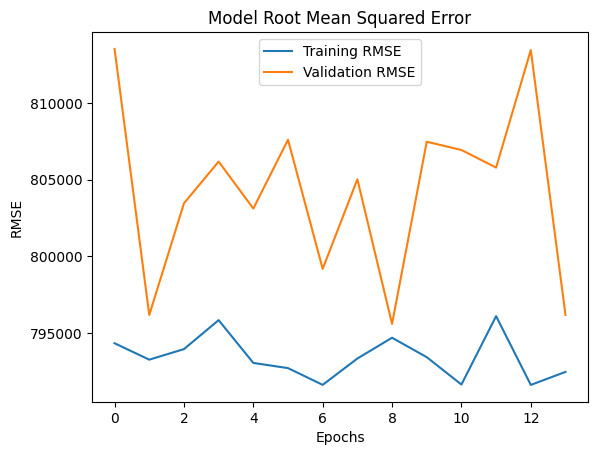

In [32]:
plt.plot(history.history['rmse'], label='Training RMSE')
plt.plot(history.history['val_rmse'], label='Validation RMSE')
plt.title('Model Root Mean Squared Error')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.legend()
plt.show()